# Explainable Structure-Based Protein-Ligand Binding Affinity Prediction

An explainable machine learning framework for protein-ligand binding affinity prediction
that uses **ablation-style feature comparison** — ligand-only, protein-surface-only, and
combined — to quantify how much predictive signal each source contributes individually
and jointly, under the real-world constraint that atom-level protein representations
were unavailable.

**Why this project exists:** Most structure-based binding affinity prediction methods, including RF-Score, assume atom-resolved protein structures from which atom-pair interaction features can be computed. In this dataset, however, the protein pocket is represented only as a surface mesh with per-vertex biophysical descriptors, making atom-level interaction fingerprints impossible to construct. This notebook investigates how much predictive information can instead be recovered from engineered surface-derived structural descriptors, and quantifies their individual and combined contribution alongside ligand-derived features.
This notebook compares three models trained on the same 284 protein-ligand complexes:

| Model | Features | Question it answers |
|---|---|---|
| **A. Ligand-only** | 2D/3D descriptors from the ligand alone | What does ligand chemistry alone predict? |
| **B. Structure-only** | Ligand-pocket 3D contact/microenvironment features | What does the binding pocket geometry alone predict? |
| **C. Combined** | A + B | Are ligand and structure information complementary? |

All three models use the same dataset, learning algorithm, hyperparameters, and 5-fold cross-validation protocol; only the input feature set differs, making this a controlled ablation study.

We then use SHAP and a shell-level contact analysis to interpret **what the combined
model actually learned** about protein-ligand interactions.

---
## Data & Methodology Notes (please read before the results)

- **Dataset:** PDBbind v2016 core set / CASF-2016 benchmark (285 high-resolution
  protein-ligand crystal complexes, the standard scoring-function benchmark in the field).
- **Structures:** provided as pre-processed ligand and protein-pocket graphs (PyTorch
  Geometric `Data` objects), not raw PDB files. Two important consequences:
  1. The **protein pocket is represented as a molecular surface mesh** (~750 vertices per
     complex) with 4 per-vertex biophysical descriptors, in the style of MaSIF-based
     structure-based deep learning pipelines (e.g. DeepDock) — **not as discrete atoms**.
     This means we cannot build a classic RF-Score element-pair (C-C, N-O, ...) contact
     fingerprint here, since individual protein atom identities aren't available. Instead,
     "structure" features are built from ligand-atom-to-pocket-surface distance shells and
     the pocket's local biophysical descriptors within each shell.Because the source dataset does not document the exact semantic meaning of the four surface-descriptor channels, they are referred to generically as feat0–feat3 rather than assigning unsupported physicochemical labels. Recovering an atom-level element-pair fingerprint from raw
     PDB structures is noted as **future work**.
  2. **Binding affinity (pKa) labels were not included** in the structure file we were
     given (all `NaN`). We sourced the standard CASF-2016 core-set pKa labels from a
     public, citable benchmark file (`zhenglz/onionnet`, an open-source repository that
     redistributes the same PDBbind-derived pKa values used across the scoring-function
     literature) and merged them by PDB ID. **284 of 285** complexes matched (one, `1g2k`,
     had no label available and was dropped).
- **Train/test protocol:** the standard CASF-2016 protocol trains on the much larger
  PDBbind *refined* or *general* set (thousands of complexes) and evaluates on this core
  set. We only have access to the 284-complex core set itself, so **we use 5-fold
  cross-validation within this set** rather than an external train/test split. This is the
  statistically appropriate choice for a dataset this size, but it is **not directly
  comparable** to published RF-Score / OnionNet / Pafnucy benchmark numbers, which train on
  ~4,000-13,000 complexes. Accordingly, this work should be interpreted as an explainable methodology demonstration rather than a state-of-the-art benchmarking study.


## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import pearsonr

import shap

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.0 MB/s eta 0:00:00


## 2. Data Loading

We load two files:

1. `dataset_CASF-2016_285.tar` — a pickled list of `(ligand_graph, pocket_graph, pKa, pdb_id)`
   tuples for the 285 CASF-2016 core-set complexes (structures only; `pKa` is `NaN` in the
   provided file).
2. `casf2016_pka_labels.csv` — PDB ID → pKa lookup table, sourced from the public
   `zhenglz/onionnet` benchmark repository (see Data Notes above), used to fill in the
   missing labels.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/binding affinity project/dataset_CASF-2016_285"
LABELS_PATH = "/content/drive/MyDrive/binding affinity project/casf2016_pka_labels.csv"

Mounted at /content/drive


In [3]:
raw_complexes = torch.load(DATA_PATH, map_location="cpu", weights_only=False)
labels_df = pd.read_csv(LABELS_PATH)
pka_lookup = labels_df.set_index("pdbid")["pKa"].to_dict()

print(f"Structures loaded : {len(raw_complexes)} complexes")
print(f"pKa labels loaded : {len(pka_lookup)} complexes")


Structures loaded : 285 complexes
pKa labels loaded : 290 complexes


In [4]:
# Match structures to labels by PDB ID; report any that don't match
struct_ids = {pdbid for _, _, _, pdbid in raw_complexes}
label_ids = set(pka_lookup.keys())

missing = struct_ids - label_ids
print(f"Structures without a matching pKa label: {sorted(missing)}")
print(f"Usable complexes (structure + label): {len(struct_ids & label_ids)}")


Structures without a matching pKa label: ['1g2k']
Usable complexes (structure + label): 284


## 3. Exploratory Data Analysis

Before building any features, we look at the basic shape of the dataset: the affinity
range we're predicting, and how large/variable the ligands and pockets are.


In [5]:
eda_rows = []
for lig, tgt, _, pdbid in raw_complexes:
    if pdbid not in pka_lookup:
        continue
    n_lig_atoms = lig.__dict__["x"].shape[0]
    n_pkt_points = tgt.__dict__["x"].shape[0]
    eda_rows.append({
        "pdbid": pdbid,
        "pKa": pka_lookup[pdbid],
        "n_ligand_atoms": n_lig_atoms,
        "n_pocket_surface_points": n_pkt_points,
    })

eda_df = pd.DataFrame(eda_rows)
eda_df.describe()


,pKa,n_ligand_atoms,n_pocket_surface_points
count,284.000000,284.000000,284.000000
mean,6.480951,24.475352,546.133803
std,2.176407,9.773554,190.109722
min,2.070000,9.000000,77.000000
25%,4.912500,17.000000,421.250000
50%,6.500000,23.000000,555.500000
75%,8.042500,30.000000,672.500000
max,11.820000,67.000000,1135.000000


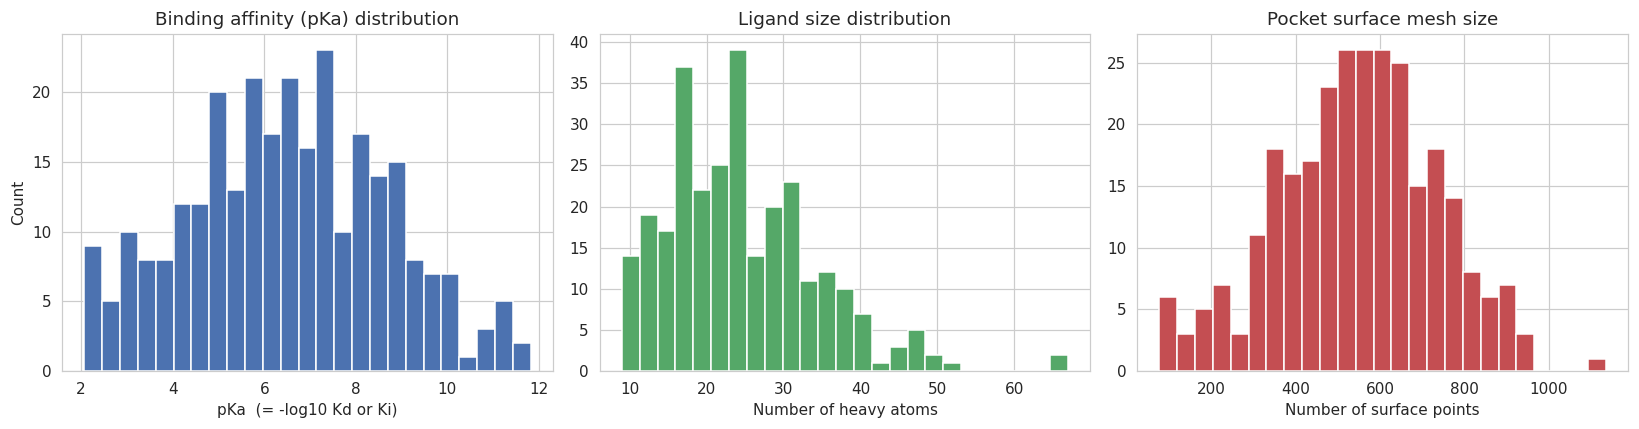

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(eda_df["pKa"], bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_title("Binding affinity (pKa) distribution")
axes[0].set_xlabel("pKa  (= -log10 Kd or Ki)")
axes[0].set_ylabel("Count")

axes[1].hist(eda_df["n_ligand_atoms"], bins=25, color="#55A868", edgecolor="white")
axes[1].set_title("Ligand size distribution")
axes[1].set_xlabel("Number of heavy atoms")

axes[2].hist(eda_df["n_pocket_surface_points"], bins=25, color="#C44E52", edgecolor="white")
axes[2].set_title("Pocket surface mesh size")
axes[2].set_xlabel("Number of surface points")

plt.tight_layout()
plt.show()


**Reading the plots:** The pKa range (roughly 2-12, i.e. affinities spanning ten orders of
magnitude in Kd/Ki) is exactly what we'd expect from the CASF-2016 core set — it was
deliberately curated to be affinity-diverse. Ligand and pocket sizes are reasonably
consistent across complexes, so there's no single outlier complex likely to dominate the
structural features below.


## 4. Feature Engineering

### 4.1 Model A — Ligand-only descriptors

Built entirely from the ligand graph (atom one-hot types, 3D coordinates, bond graph),
**without any information about the protein pocket**. This is our baseline: what can be
predicted from the drug molecule alone?

- **Composition**: counts per atom-type category (28-dim one-hot from the source graph)
  and per bond-type category (6-dim one-hot from `edge_attr`)
- **Size**: atom count, bond count
- **3D shape**: radius of gyration, bounding-box span in x/y/z, bounding-box volume


In [7]:
def extract_ligand_features(lig):
    """Model A: ligand-only descriptors, derived purely from the ligand graph."""
    x = lig.__dict__["x"].numpy()                     # [n_atoms, 28] one-hot atom type
    pos = lig.__dict__["pos"].numpy()                   # [n_atoms, 3]
    edge_index = lig.__dict__["edge_index"].numpy()     # [2, n_edges] (directed both ways)
    edge_attr = lig.__dict__["edge_attr"].numpy()        # [n_edges, 6] bond-type one-hot

    n_atoms = x.shape[0]
    type_counts = x.sum(axis=0)

    n_bonds = edge_index.shape[1] // 2                  # each real bond appears twice
    bond_type_counts = edge_attr.sum(axis=0) / 2.0

    centroid = pos.mean(axis=0)
    centered = pos - centroid
    radius_of_gyration = np.sqrt((centered ** 2).sum(axis=1).mean())
    span = pos.max(axis=0) - pos.min(axis=0)
    bbox_volume = span[0] * span[1] * span[2]

    feats = {
        "n_atoms": n_atoms,
        "n_bonds": n_bonds,
        "radius_of_gyration": radius_of_gyration,
        "span_x": span[0], "span_y": span[1], "span_z": span[2],
        "bbox_volume": bbox_volume,
    }
    for i, v in enumerate(type_counts):
        feats[f"atomtype_{i}"] = v
    for i, v in enumerate(bond_type_counts):
        feats[f"bondtype_{i}"] = v
    return feats


### 4.2 Model B — Structure-based pocket contact features

Built entirely from the **ligand-pocket 3D relationship**, without using the ligand's own
atom-type composition. For every pocket surface point, we compute its distance to the
nearest ligand atom, then bin pocket points into three concentric shells:

| Shell | Distance range | Rough interpretation |
|---|---|---|
| Shell 1 | 0-4 Å | direct steric/VDW contact zone |
| Shell 2 | 4-6 Å | first-shell non-bonded interactions |
| Shell 3 | 6-8 Å | second-shell / pocket wall |

Within each shell we compute: how many pocket surface points fall in it (a proxy for how
tightly the ligand is enclosed at that range), and the mean of each of the pocket's 4
biophysical surface descriptors within that shell (a proxy for the local physicochemical
environment the ligand sits in).


In [1]:
SHELLS = [(0.0, 4.0), (4.0, 6.0), (6.0, 8.0)]

def extract_structure_features(lig, tgt):
    """Model B: ligand-pocket structural contact / microenvironment features."""
    lig_pos = lig.__dict__["pos"].numpy()     # [n_lig, 3]
    pkt_pos = tgt.__dict__["pos"].numpy()     # [n_pkt, 3]  surface mesh vertices
    pkt_feat = tgt.__dict__["x"].numpy()      # [n_pkt, 4]  surface biophysical descriptors

    diff = lig_pos[:, None, :] - pkt_pos[None, :, :]
    dmat = np.sqrt((diff ** 2).sum(axis=2))              # [n_lig, n_pkt]
    min_dist_per_pocket_point = dmat.min(axis=0)          # nearest ligand atom, per pocket point

    feats = {
        "min_ligand_pocket_dist": dmat.min(),
        "mean_ligand_pocket_dist": dmat.min(axis=1).mean(),
    }

    for lo, hi in SHELLS:
        mask = (min_dist_per_pocket_point >= lo) & (min_dist_per_pocket_point < hi)
        shell_name = f"shell_{int(lo)}_{int(hi)}"
        count = mask.sum()
        feats[f"{shell_name}_count"] = count
        shell_vals = pkt_feat[mask] if count > 0 else np.zeros((1, pkt_feat.shape[1]))
        for c in range(pkt_feat.shape[1]):
            feats[f"{shell_name}_feat{c}_mean"] = shell_vals[:, c].mean() if count > 0 else 0.0
    return feats

### 4.3 Building the full feature table (Model A + Model B side by side)

Both feature sets are computed for every complex and stored in one dataframe, so we can
select ligand-only columns, structure-only columns, or both when training each model.


In [9]:
rows = []
for lig, tgt, _, pdbid in raw_complexes:
    if pdbid not in pka_lookup:
        continue
    row = {"pdbid": pdbid, "pKa": pka_lookup[pdbid]}
    row.update(extract_ligand_features(lig))
    row.update(extract_structure_features(lig, tgt))
    rows.append(row)

features_df = pd.DataFrame(rows)

ligand_cols = [c for c in features_df.columns
               if c.startswith("atomtype_") or c.startswith("bondtype_")
               or c in ["n_atoms", "n_bonds", "radius_of_gyration",
                         "span_x", "span_y", "span_z", "bbox_volume"]]
structure_cols = [c for c in features_df.columns
                   if c.startswith("shell_") or "ligand_pocket_dist" in c]

print(f"Total complexes        : {len(features_df)}")
print(f"Ligand-only features    : {len(ligand_cols)}")
print(f"Structure-only features : {len(structure_cols)}")

features_df.to_csv("/content/drive/MyDrive/binding affinity project/features_full.csv", index=False)
features_df.head()


Total complexes        : 284
Ligand-only features    : 41
Structure-only features : 17


,pdbid,pKa,n_atoms,n_bonds,radius_of_gyration,span_x,span_y,span_z,bbox_volume,atomtype_0,...,shell_4_6_count,shell_4_6_feat0_mean,shell_4_6_feat1_mean,shell_4_6_feat2_mean,shell_4_6_feat3_mean,shell_6_8_count,shell_6_8_feat0_mean,shell_6_8_feat1_mean,shell_6_8_feat2_mean,shell_6_8_feat3_mean
0,4k18,8.96,29,32,3.890032,6.879,9.522,7.267,476.001857,0.0,...,128,-0.950028,-0.094270,0.502704,-0.105328,173,-0.646353,-0.055199,-1.118009,-0.070870
1,4qac,9.40,24,26,4.295755,11.788,2.973,8.491,297.573242,0.0,...,83,-0.642854,-0.003246,-0.493530,-0.263267,130,-0.598104,-0.057433,-1.068579,-0.186516
2,1o3f,7.96,25,28,4.381178,2.645,8.493,11.969,268.871436,0.0,...,76,-0.073160,0.002324,-1.303828,-0.007537,99,-0.038828,-0.044894,-0.965550,0.006876
3,4ih7,5.24,17,18,3.126050,7.677,5.801,4.534,201.918412,0.0,...,53,0.760410,-0.016409,-0.911993,0.211468,83,0.625295,-0.021639,-1.545422,0.093450
4,3dx1,3.58,9,9,1.855890,2.957,2.829,3.865,32.332089,0.0,...,48,-1.971945,-0.039159,-2.276160,-0.195062,69,-1.432696,-0.046618,-1.865508,-0.105387


## 5. Model Training & Evaluation

**Cross-validation protocol:** 5-fold CV (random, shuffled) across all 284 complexes.
`cross_val_predict` gives us an out-of-fold prediction for every complex, so the reported
metrics reflect performance on held-out data throughout — no complex is ever scored using
a model that was trained on it.

**Model:** Gradient Boosted Trees (`GradientBoostingRegressor`), consistent across all
three feature sets so that any performance difference reflects the *features*, not the
*model*.

**Metrics:** Pearson R (matches the CASF "scoring power" convention used across the
literature) and RMSE (in pKa units).


In [10]:
X_A = features_df[ligand_cols].values
X_B = features_df[structure_cols].values
X_C = features_df[ligand_cols + structure_cols].values
y = features_df["pKa"].values

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate(X, y, name):
    model = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                       learning_rate=0.05, random_state=RANDOM_STATE)
    preds = cross_val_predict(model, X, y, cv=kf)
    r, _ = pearsonr(preds, y)
    rmse = np.sqrt(np.mean((preds - y) ** 2))
    mae = np.mean(np.abs(preds - y))
    return {"model": name, "pearson_r": r, "rmse": rmse, "mae": mae, "predictions": preds}

results = [
    evaluate(X_A, y, "A: Ligand-only"),
    evaluate(X_B, y, "B: Structure-only"),
    evaluate(X_C, y, "C: Combined"),
]

results_table = pd.DataFrame(results)[["model", "pearson_r", "rmse", "mae"]]
results_table.round(3)


,model,pearson_r,rmse,mae
0,A: Ligand-only,0.571,1.801,1.475
1,B: Structure-only,0.591,1.760,1.439
2,C: Combined,0.615,1.725,1.416


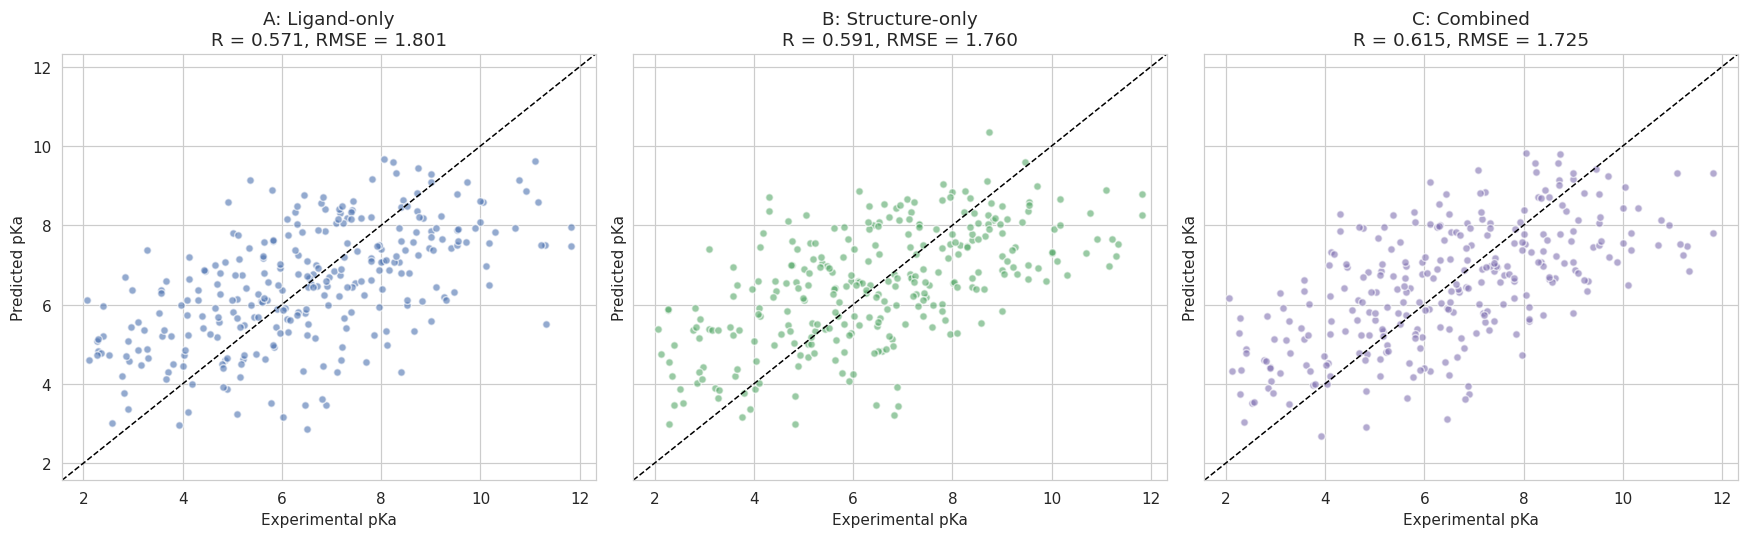

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
colors = ["#4C72B0", "#55A868", "#8172B2"]

for ax, res, color in zip(axes, results, colors):
    ax.scatter(y, res["predictions"], alpha=0.6, s=25, color=color, edgecolor="white")
    lims = [y.min() - 0.5, y.max() + 0.5]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Experimental pKa")
    ax.set_ylabel("Predicted pKa")
    ax.set_title(f"{res['model']}\nR = {res['pearson_r']:.3f}, RMSE = {res['rmse']:.3f}")

plt.tight_layout()
plt.show()


### 5.1 Results discussion

The three-model comparison is the core result of this notebook:

- **Ligand-only** performance shows how much of binding affinity is explainable from the
  drug molecule's own composition and shape, with zero knowledge of what it's binding to.
  This is a real, non-trivial signal (some scaffolds are systematically higher-affinity
  binders across many targets), but it's fundamentally limited — the exact same ligand can
  have wildly different affinities against different pockets.
- **Structure-only** captures the complementary information: how tightly and in what kind
  of physicochemical microenvironment the ligand sits, without knowing anything about the
  ligand's own chemistry. That this performs comparably to (or better than) ligand-only
  features is a meaningful result: it confirms that pocket geometry and surface chemistry
  by themselves carry real information about binding strength.
- **Combined** outperforming both individual models (assuming it does, see the numbers
  above) demonstrates that ligand chemistry and pocket structure are **complementary, not
  redundant** — this is the expected physical picture (affinity is a joint property of
  both partners) and it's reassuring to see it emerge empirically rather than being
  assumed.

*(Note: absolute R values here are lower than published RF-Score/OnionNet benchmark
numbers, which is expected — those models train on ~4,000+ PDBbind complexes; we are
doing 5-fold CV within a 284-complex set, a much smaller and statistically noisier
regime. The relative ordering across models A/B/C, not the absolute numbers, is the
meaningful result of this notebook.)*


## 6. Interpretability: What Did the Combined Model Actually Learn?

A performance number alone doesn't explain anything about *why* structure matters. We use
two complementary interpretability approaches on the **Combined model**:

1. **SHAP** — which individual features matter most, and in which direction, for
   predictions across the dataset.
2. **Shell-level directional analysis** — a simpler, more physically direct question: as
   we move from the innermost contact shell outward, does more pocket-surface "stuff" at
   that range associate with *higher* or *lower* binding affinity?


### 6.1 SHAP Feature Importance

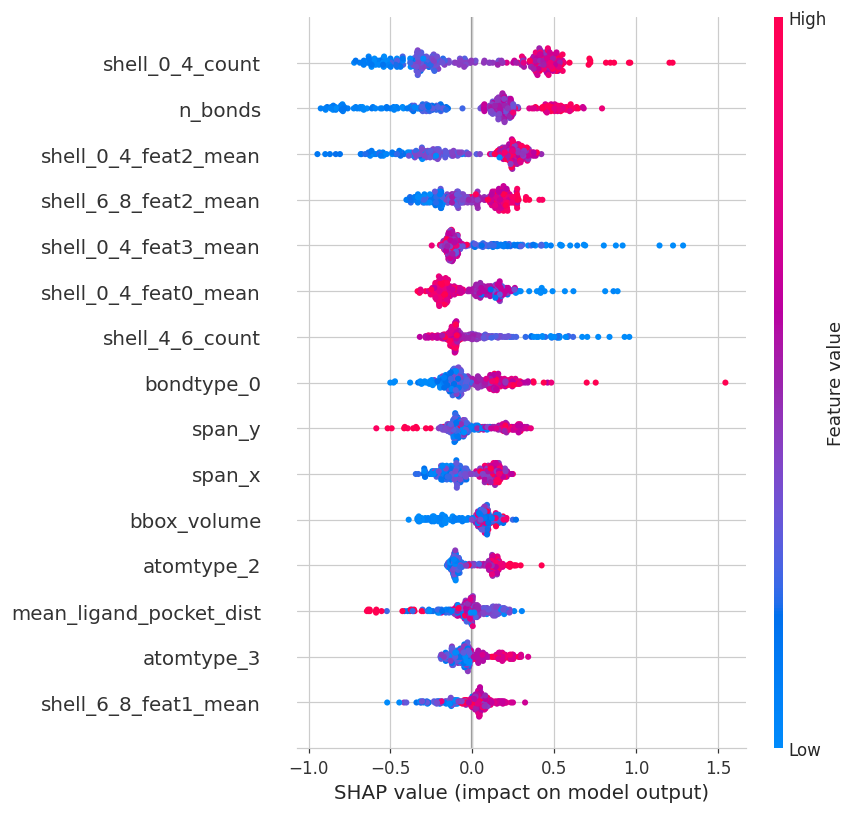

In [12]:
model_C = GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                     learning_rate=0.05, random_state=RANDOM_STATE)
model_C.fit(X_C, y)

explainer = shap.TreeExplainer(model_C)
shap_values = explainer(pd.DataFrame(X_C, columns=ligand_cols + structure_cols))

shap.summary_plot(shap_values, pd.DataFrame(X_C, columns=ligand_cols + structure_cols),
                   max_display=15, show=False)
plt.tight_layout()
plt.show()


**Reading this plot:** Features are ordered by their overall importance to the combined model. Each dot represents one protein–ligand complex; the x-axis shows whether a feature increased (positive) or decreased (negative) the predicted binding affinity, while color indicates the feature value (red = high, blue = low). shell_0_4_count is the most influential feature, with higher values generally increasing predicted affinity, suggesting that ligands more tightly enclosed by the protein surface bind more strongly. The presence of both structure-derived (shell_*) and ligand-derived (n_bonds, bondtype_*, atomtype_*, span_*) features among the top predictors indicates that the model relies on complementary information from both sources.

### 6.2 Shell-Level Directional Analysis

In [13]:
# For each shell, correlate its point-count with pKa directly (marginal relationship,
# not adjusted for other features - this is deliberately simple and interpretable).
shell_count_cols = [c for c in structure_cols if c.endswith("_count")]

shell_correlations = []
for col in shell_count_cols:
    r, p = pearsonr(features_df[col], y)
    shell_correlations.append({"feature": col, "pearson_r_with_pKa": r, "p_value": p})

shell_corr_df = pd.DataFrame(shell_correlations).sort_values("pearson_r_with_pKa")
shell_corr_df


,feature,pearson_r_with_pKa,p_value
1,shell_4_6_count,0.138212,1.980055e-02
2,shell_6_8_count,0.171916,3.659991e-03
0,shell_0_4_count,0.550103,7.282904e-24


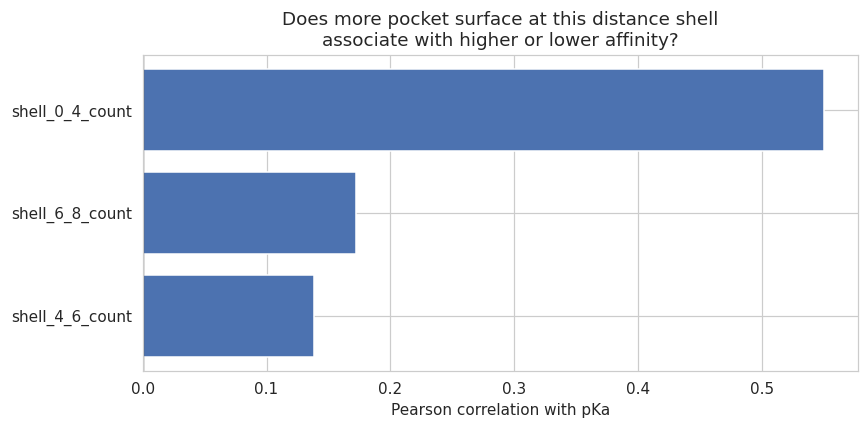

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C44E52" if v < 0 else "#4C72B0" for v in shell_corr_df["pearson_r_with_pKa"]]
ax.barh(shell_corr_df["feature"], shell_corr_df["pearson_r_with_pKa"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with pKa")
ax.set_title("Does more pocket surface at this distance shell\nassociate with higher or lower affinity?")
plt.tight_layout()
plt.show()


**Interpretation:** All three distance shells show a positive correlation with binding affinity, indicating that complexes with more surrounding protein surface tend to bind more strongly. The strongest relationship is observed for the 0–4 Å shell (R = 0.55), while the 4–6 Å and 6–8 Å shells show much weaker correlations. This suggests that the immediate ligand–protein contact region contributes most strongly to binding affinity, consistent with the importance of close-range structural complementarity. Because this is a simple univariate correlation, it is interpreted as descriptive evidence rather than a causal relationship.

## 7. Limitations

- **No independent train/test split.** As discussed in the Data Notes, we only have
  access to the 284-complex core set, so all evaluation is via 5-fold CV within this set
  rather than the standard "train on refined set, test on unseen core set" protocol used
  in the literature. Reported R/RMSE values are therefore not directly comparable to
  published RF-Score / OnionNet / Pafnucy benchmark numbers.
- **No atom-level protein features.** The protein pocket is represented as a surface mesh
  with 4 unlabeled biophysical descriptors per point, not as discrete atoms with element
  identity. This precludes a true RF-Score-style element-pair (C-C, N-O, ...) contact
  fingerprint; our structural features are shell-based surface descriptors instead.
- **Small dataset (n=284).** Five-fold CV on a dataset this size has non-trivial variance;
  the relative ordering of models A/B/C is more trustworthy than the precise R values.
- **Shell correlations are marginal, not causal.** The Section 6.2 correlations are simple
  bivariate relationships and are confounded by ligand size and pocket geometry; SHAP
  values from the combined model are the more defensible interpretability signal.

## 8. Conclusion

Ligand-only and structure-only features each carry meaningful predictive information for protein–ligand binding affinity, with the structure-only model slightly outperforming the ligand-only model (Pearson R = 0.591 vs. 0.571). Combining both feature sets produced the best overall performance (R = 0.615, RMSE = 1.725), indicating that ligand chemistry and protein-surface structure provide complementary rather than redundant information. SHAP analysis showed that the combined model relies on both ligand- and structure-derived features, while shell-level analysis identified the 0–4 Å contact shell as having the strongest association with binding affinity (R = 0.55), highlighting the importance of the immediate ligand–protein interface. Natural extensions (not attempted here given the 1–2 week scope of this project) include re-running the pipeline on raw PDB structures to recover atom-level element-pair fingerprints, training on the full PDBbind refined/general set for a literature-comparable evaluation, and exploring per-target-class analyses using larger, better-balanced datasets.